# EDA - Ocorrências Aeronáuticas

Este notebook documenta a análise exploratória mínima exigida para o desafio. A variável-alvo é `Classificacao_da_Ocorrencia`, tratada como um problema de classificação binária entre `Acidente` e `Incidente Grave`.

O dataset usado na EDA é o arquivo pré-tratado `ocorrencia_pre_tratado.csv`, que remove colunas com vazamento de informação pós-ocorrência, como danos e lesões.


## 1. Carregamento e inspeção inicial


In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 120)

df = pd.read_csv("ocorrencia_pre_tratado.csv")
TARGET = "Classificacao_da_Ocorrencia"

NUMERIC_FEATURES = ["PMD", "Numero_de_Assentos"]
CATEGORICAL_FEATURES = ["Fase_da_Operacao", "Regiao", "Operacao"]
CATEGORIA = NUMERIC_FEATURES + CATEGORICAL_FEATURES

In [70]:
df.head()

,Numero_da_Ocorrencia,Numero_da_Ficha,Operador_Padronizado,Classificacao_da_Ocorrencia,Data_da_Ocorrencia,Hora_da_Ocorrencia,Municipio,UF,Regiao,Descricao_do_Tipo,ICAO,Latitude,Longitude,Tipo_de_Aerodromo,Historico,Matricula,Categoria_da_Aeronave,Operador,Tipo_de_Ocorrencia,Fase_da_Operacao,Operacao,Aerodromo_de_Destino,Aerodromo_de_Origem,Modelo,CLS,Tipo_ICAO,PMD,Numero_de_Assentos,Nome_do_Fabricante,PSSO
0,25626,202096550,MINIST.JUST.SECRET.NAC.DE SEG.PUB.,Acidente,2020-10-08,16:00,CORUMBÁ,MS,Centro-Oeste,FALHA OU MAU FUNCIONAMENTO DO MOTOR,Fora de Aeródromo,"-17,4417","-56,8269",-,A aeronave decolou do Aeroporto Internacional ...,PRMJZ,ADF,MINIST.JUST.SECRET.NAC.DE SEG.PUB.,SCF-PP,Cruzeiro,Operação Pública,SJQI,SBCR,AS 350 B2,H1T,AS50,2250.0,6.0,EUROCOPTER FRANCE,verdadeiro
1,26304,202056314,AERO AGRICOLA ROSARIENSE LTDA,Acidente,2020-12-09,21:30:00,SANT'ANA DO LIVRAMENTO,RS,Sul,COMBUSTÍVEL,Fora de Aeródromo,"-30,6056","-55,0564",-,A aeronave decolou da pista pouso eventual da ...,PRREN,S11,AERO AGRICOLA ROSARIENSE LTDA,FUEL,Voo a baixa altura,Operação Agrícola,NaN,NaN,A188B,L1P,C188,1905.0,1.0,CESSNA AIRCRAFT,verdadeiro
2,25763,202041291,KAIO GENARIO FERREIRA DE MELO,Acidente,2020-10-15,11:00,RIO CLARO,RJ,Sudeste,PERDA DE CONTROLE EM VOO,Fora de Aeródromo,"-22,7031","-43,9947",-,A aeronave decolou de local desconhecido para ...,PRESK,TPP,KAIO GENARIO FERREIRA DE MELO,LOC-I,Cruzeiro,Voo Privado,NaN,NaN,R44,H1P,R44,1088.0,4.0,ROBINSON HELICOPTER,verdadeiro
3,26123,202060427,MARCIO ROBERTO SALES DE ARAUJO,Acidente,2020-11-19,15:00,IPIXUNA DO PARÁ,PA,Norte,OUTROS,Aeródromo não cadastrado,"-2,52357","-47,5181",NaN,A AERONAVE DECOLOU DE UMA PISTA DESCONHECIDA C...,PTOQB,TPP,MARCIO ROBERTO SALES DE ARAUJO,OTHR,Pouso,Voo Privado,NaN,NaN,58TC,L2P,BE58,2767.0,6.0,BEECH AIRCRAFT,falso
4,5390,/2003,NaN,Acidente,2003-12-09,NaN,NaN,Indeterminado,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N32TJ,ESTRANGEIRA,NaN,NaN,NaN,Voo Privado,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,verdadeiro


In [71]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5021 entries, 0 to 5020
Data columns (total 30 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Numero_da_Ocorrencia         5021 non-null   int64  
 1   Numero_da_Ficha              5019 non-null   str    
 2   Operador_Padronizado         4945 non-null   str    
 3   Classificacao_da_Ocorrencia  5021 non-null   str    
 4   Data_da_Ocorrencia           5021 non-null   str    
 5   Hora_da_Ocorrencia           3588 non-null   str    
 6   Municipio                    3627 non-null   str    
 7   UF                           5018 non-null   str    
 8   Regiao                       4351 non-null   str    
 9   Descricao_do_Tipo            4379 non-null   str    
 10  ICAO                         1687 non-null   str    
 11  Latitude                     3531 non-null   str    
 12  Longitude                    3531 non-null   str    
 13  Tipo_de_Aerodromo            

In [72]:
df.describe(include="all")

,Numero_da_Ocorrencia,Numero_da_Ficha,Operador_Padronizado,Classificacao_da_Ocorrencia,Data_da_Ocorrencia,Hora_da_Ocorrencia,Municipio,UF,Regiao,Descricao_do_Tipo,ICAO,Latitude,Longitude,Tipo_de_Aerodromo,Historico,Matricula,Categoria_da_Aeronave,Operador,Tipo_de_Ocorrencia,Fase_da_Operacao,Operacao,Aerodromo_de_Destino,Aerodromo_de_Origem,Modelo,CLS,Tipo_ICAO,PMD,Numero_de_Assentos,Nome_do_Fabricante,PSSO
count,5021.000000,5019,4945,5021,5021,3588,3627,5018,4351,4379,1687,3531,3531,1572,4756,5017,5012,4945,4379,3721,4927,2883,2904,4858,4846,4863,4876.000000,4872.000000,4730,5021
unique,NaN,3290,3044,2,3268,697,1333,29,5,34,295,2430,2439,5,4038,3815,57,3280,34,27,12,820,804,747,16,217,NaN,NaN,350,2
top,NaN,/2009,AEROCLUBE DE BRAGANCA PAULISTA,Acidente,2024-02-12,20:00:00,GOIÂNIA,SP,Sudeste,FALHA OU MAU FUNCIONAMENTO DO MOTOR,Fora de Aeródromo,"-23,1817","-46,9436",-,A aeronave decolou da Pista Campo Limpo (ZZZZ)...,*****,TPP,AEROCLUBE DE BRAGANÇA PAULISTA,SCF-PP,Pouso,Voo Privado,XXXX,XXXX,EMB-202,L1P,IPAN,NaN,NaN,NEIVA,verdadeiro
freq,NaN,118,33,3704,8,96,71,848,1410,782,799,19,20,799,6,14,1871,26,782,781,2268,199,194,196,3044,618,NaN,NaN,929,4963
mean,12814.381000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3528.873052,7.507594,NaN,NaN
std,13129.158692,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13279.101698,23.691526,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN
25%,4529.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1043.000000,2.000000,NaN,NaN
50%,6532.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1633.000000,4.000000,NaN,NaN
75%,25190.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2155.000000,6.000000,NaN,NaN


In [73]:
df.dtypes.sort_index()

Aerodromo_de_Destino               str
Aerodromo_de_Origem                str
CLS                                str
Categoria_da_Aeronave              str
Classificacao_da_Ocorrencia        str
Data_da_Ocorrencia                 str
Descricao_do_Tipo                  str
Fase_da_Operacao                   str
Historico                          str
Hora_da_Ocorrencia                 str
ICAO                               str
Latitude                           str
Longitude                          str
Matricula                          str
Modelo                             str
Municipio                          str
Nome_do_Fabricante                 str
Numero_da_Ficha                    str
Numero_da_Ocorrencia             int64
Numero_de_Assentos             float64
Operacao                           str
Operador                           str
Operador_Padronizado               str
PMD                            float64
PSSO                               str
Regiao                   

**Comentários sobre tipos de dados**

- `Data_da_Ocorrencia` é carregada como `object`; deve ser convertida para `datetime` antes de usar ano, mês, ordenação temporal ou validação de datas.
- `Hora_da_Ocorrencia` também vem como `object`; isso é aceitável para uma EDA inicial, mas exigiria padronização se fosse usada como feature temporal.
- `Latitude` e `Longitude` vêm como `object` porque usam vírgula decimal no CSV; precisam de conversão para `float` caso sejam usadas em mapas ou distâncias.
- `Numero_da_Ocorrencia` e `Numero_da_Ficha` são identificadores. Mesmo quando numéricos, não devem entrar diretamente na modelagem por não representarem características generalizáveis.
- `PMD` e `Numero_de_Assentos` foram reconhecidas como numéricas e serão analisadas como features quantitativas.


## Remoção de vazamento de dados


As colunas de danos à aeronave e lesões descrevem consequências observadas depois da ocorrência. Elas foram removidas antes da EDA principal porque não estariam disponíveis antes do evento e causariam vazamento de dados na modelagem.


In [74]:
LEAKAGE_COLUMNS = [
    "Danos_a_Aeronave",
    "Lesoes_Fatais_Tripulantes", "Lesoes_Fatais_Passageiros", "Lesoes_Fatais_Terceiros",
    "Lesoes_Graves_Tripulantes", "Lesoes_Graves_Passageiros", "Lesoes_Graves_Terceiros",
    "Lesoes_Leves_Tripulantes", "Lesoes_Leves_Passageiros", "Lesoes_Leves_Terceiros",
    "Ilesos_Tripulantes", "Ilesos_Passageiros",
    "Lesoes_Desconhecidas_Tripulantes", "Lesoes_Desconhecidas_Passageiros", "Lesoes_Desconhecidas_Terceiros",
]

leakage_present = [col for col in LEAKAGE_COLUMNS if col in df.columns]
print("Colunas de vazamento ainda presentes:", leakage_present)
print("Dataset atual já está sem essas colunas." if not leakage_present else "Remover antes da modelagem.")


Colunas de vazamento ainda presentes: []
Dataset atual já está sem essas colunas.


## 2. Distribuição da variável-alvo


In [75]:
target_counts = df[TARGET].value_counts(dropna=False)
target_percent = df[TARGET].value_counts(normalize=True, dropna=False).mul(100).round(2)

target_distribution = pd.DataFrame({
    "quantidade": target_counts,
    "percentual": target_percent,
})
target_distribution


,quantidade,percentual
Classificacao_da_Ocorrencia,,
Acidente,3704,73.77
Incidente Grave,1317,26.23


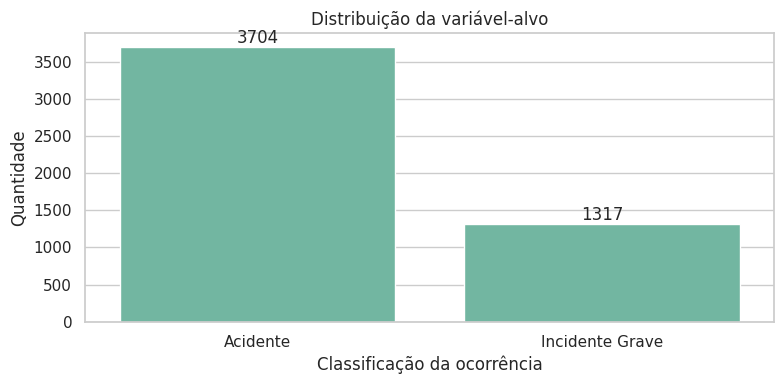

In [76]:
fig, ax = plt.subplots(figsize=(8, 4))
order = target_counts.index
sns.countplot(data=df, x=TARGET, order=order, ax=ax)
ax.set_title("Distribuição da variável-alvo")
ax.set_xlabel("Classificação da ocorrência")
ax.set_ylabel("Quantidade")
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()


**Diagnóstico**

A classe `Acidente` representa aproximadamente 74% dos registros, enquanto `Incidente Grave` representa cerca de 26%. Há desbalanceamento moderado, então a modelagem deve evitar depender apenas de acurácia. Métricas como `f1_macro`, `recall` por classe e matriz de confusão serão mais informativas; também vale testar `class_weight` ou amostragem estratificada.


## 3. Distribuições das features numéricas


In [77]:
df[NUMERIC_FEATURES].describe().T

,count,mean,std,min,25%,50%,75%,max
PMD,4876.0,3528.873052,13279.101698,0.0,1043.0,1633.0,2155.0,346544.0
Numero_de_Assentos,4872.0,7.507594,23.691526,0.0,2.0,4.0,6.0,399.0


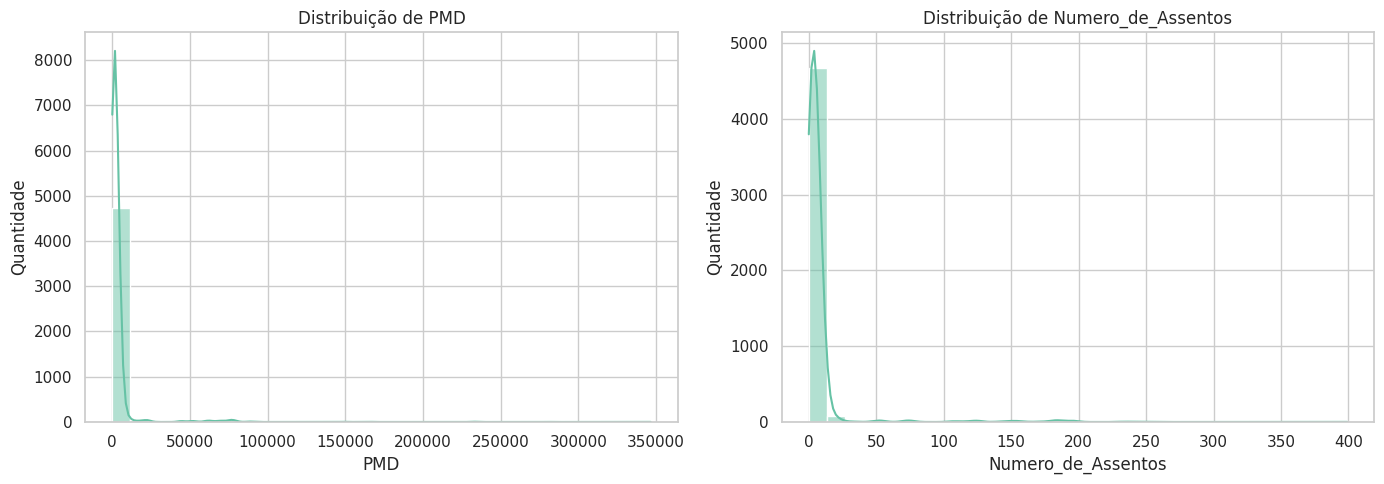

In [78]:
fig, axes = plt.subplots(1, len(NUMERIC_FEATURES), figsize=(14, 5))

for ax, col in zip(axes, NUMERIC_FEATURES):
    sns.histplot(data=df, x=col, kde=True, bins=30, ax=ax)
    ax.set_title(f"Distribuição de {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Quantidade")

plt.tight_layout()
plt.show()

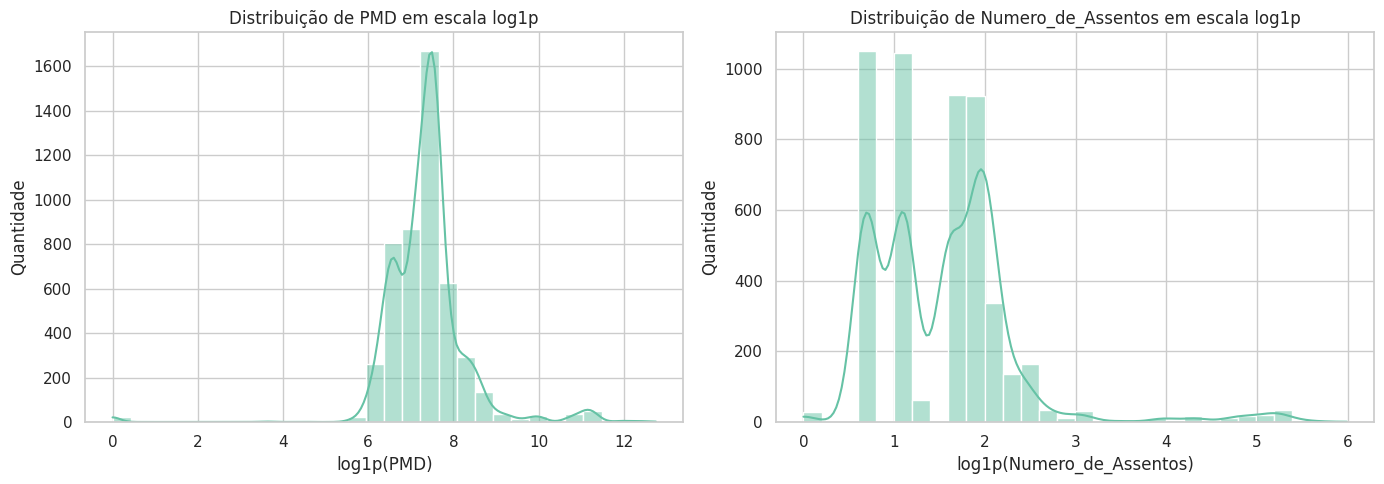

In [79]:
df_log = df.copy()
for col in NUMERIC_FEATURES:
    df_log[f"{col}_log"] = np.log1p(df_log[col])

fig, axes = plt.subplots(1, len(NUMERIC_FEATURES), figsize=(14, 5))

for ax, col in zip(axes, NUMERIC_FEATURES):
    sns.histplot(data=df_log, x=f"{col}_log", kde=True, bins=30, ax=ax)
    ax.set_title(f"Distribuição de {col} em escala log1p")
    ax.set_xlabel(f"log1p({col})")
    ax.set_ylabel("Quantidade")

plt.tight_layout()
plt.show()


**Diagnóstico**

`PMD` e `Numero_de_Assentos` apresentam forte assimetria à direita: a maior parte das aeronaves tem baixo peso e poucos assentos, mas há aeronaves muito maiores. A transformação `log1p` melhora a leitura dos histogramas e deve ser considerada na modelagem, especialmente para modelos sensíveis à escala e a outliers.


## 4. Distribuições das features categóricas

In [80]:
for col in CATEGORICAL_FEATURES:
    print(f"\n{col}")
    display(pd.DataFrame({
        "quantidade": df[col].value_counts(dropna=False),
        "percentual": df[col].value_counts(normalize=True, dropna=False).mul(100).round(2),
    }).head(20))



Fase_da_Operacao


,quantidade,percentual
Fase_da_Operacao,,
NaN,1300,25.89
Pouso,781,15.55
Decolagem,630,12.55
Corrida após pouso,505,10.06
Em rota,355,7.07
Manobra,273,5.44
Cruzeiro,184,3.66
Subida,165,3.29
Aproximação,146,2.91



Regiao


,quantidade,percentual
Regiao,,
Sudeste,1410,28.08
Centro-Oeste,1046,20.83
Sul,791,15.75
NaN,670,13.34
Norte,636,12.67
Nordeste,468,9.32



Operacao


,quantidade,percentual
Operacao,,
Voo Privado,2268,45.17
Operação Agrícola,887,17.67
Voo de Instrução,733,14.60
Táxi Aéreo,513,10.22
Voo Regular,147,2.93
Operação Pública,119,2.37
Operação Especializada,112,2.23
NaN,94,1.87
Voo Experimental,81,1.61


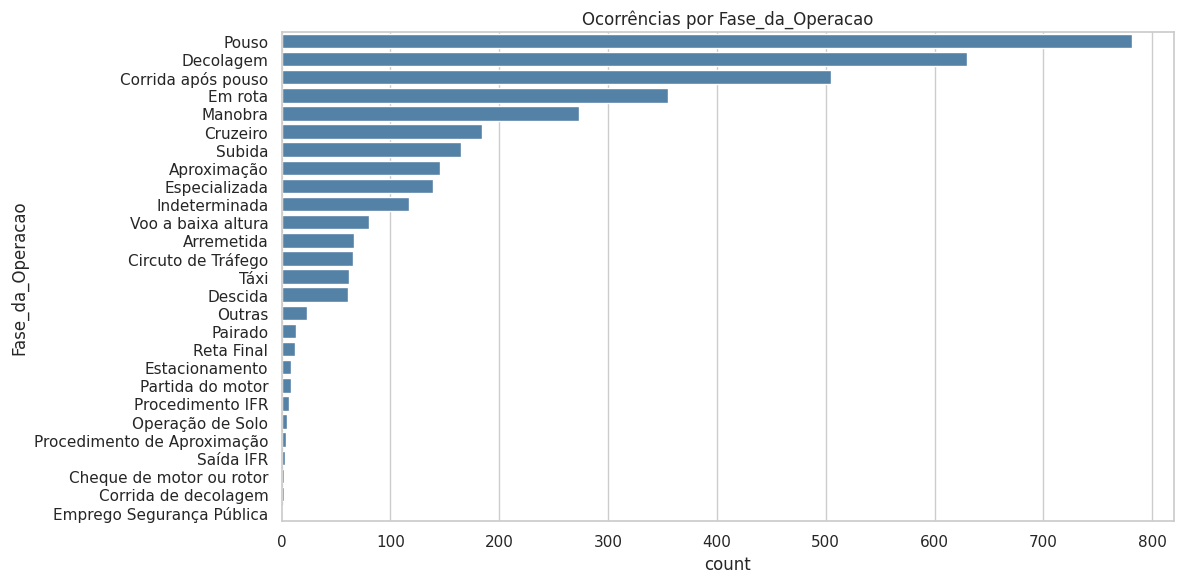

Fase_da_Operacao
Pouso                          781
Decolagem                      630
Corrida após pouso             505
Em rota                        355
Manobra                        273
Cruzeiro                       184
Subida                         165
Aproximação                    146
Especializada                  139
Indeterminada                  117
Voo a baixa altura              80
Arremetida                      67
Circuto de Tráfego              66
Táxi                            62
Descida                         61
Outras                          23
Pairado                         13
Reta Final                      12
Estacionamento                   9
Partida do motor                 9
Procedimento IFR                 7
Operação de Solo                 5
Procedimento de Aproximação      4
Saída IFR                        3
Cheque de motor ou rotor         2
Corrida de decolagem             2
Emprego Segurança Pública        1
Name: count, dtype: int64

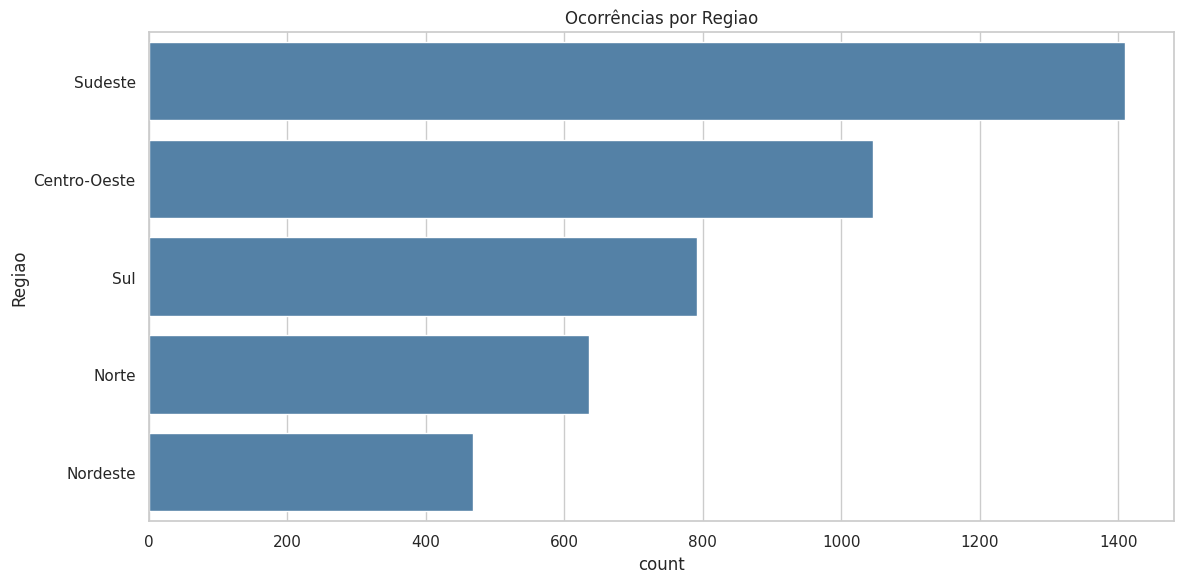

Regiao
Sudeste         1410
Centro-Oeste    1046
Sul              791
Norte            636
Nordeste         468
Name: count, dtype: int64

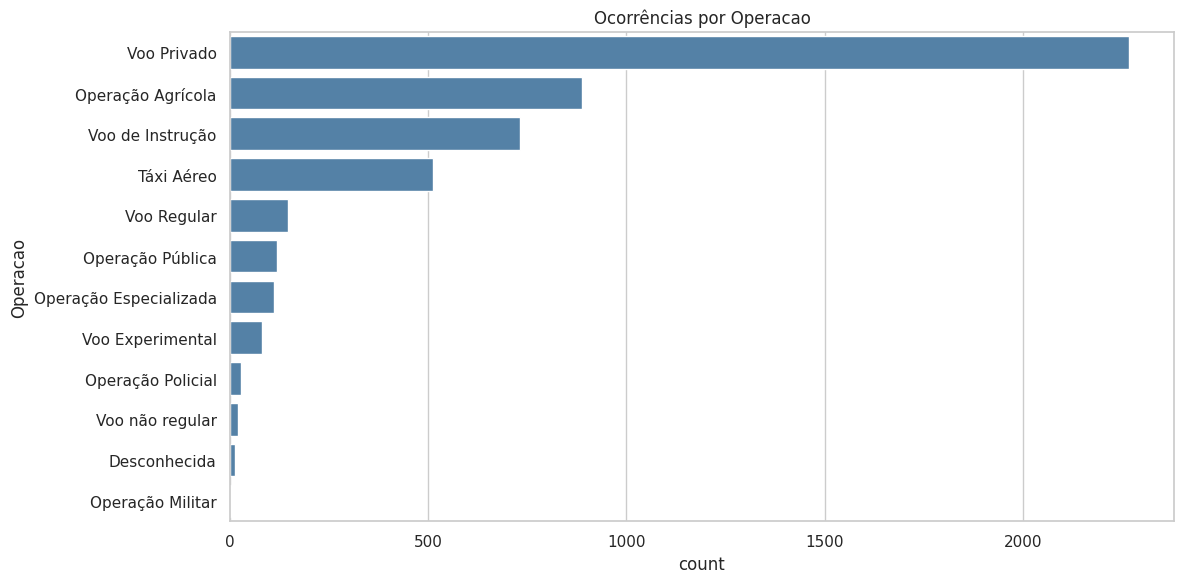

Operacao
Voo Privado               2268
Operação Agrícola          887
Voo de Instrução           733
Táxi Aéreo                 513
Voo Regular                147
Operação Pública           119
Operação Especializada     112
Voo Experimental            81
Operação Policial           29
Voo não regular             21
Desconhecida                14
Operação Militar             3
Name: count, dtype: int64

In [85]:
for i in CATEGORICAL_FEATURES:
    # Exemplo 1: Fase da Operação
    plt.figure(figsize=(12, 6))
    # Usando o order para ordenar as barras da maior para a menor
    ordem_fase = df[i].value_counts().index
    sns.countplot(data=df, y=i, order=ordem_fase, color='steelblue')
    plt.title(f'Ocorrências por {i}')
    plt.tight_layout()
    plt.show()

    # Exiba também o value_counts para checar a alta cardinalidade ou categorias raras
    display(df[i].value_counts())

In [ ]:
categorical_cols = df.select_dtypes(include="object").columns
cardinality = pd.DataFrame({
    "cardinalidade": df[categorical_cols].nunique(dropna=False),
    "categorias_raras_ate_1pct": [
        (df[col].value_counts(normalize=True, dropna=False).mul(100) <= 1).sum()
        for col in categorical_cols
    ],
}).sort_values("cardinalidade", ascending=False)

cardinality.head(20)

/tmp/ipykernel_14678/1704607020.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns


,cardinalidade,categorias_raras_ate_1pct
Historico,4039,4038
Matricula,3816,3816
Numero_da_Ficha,3291,3281
Operador,3281,3280
Data_da_Ocorrencia,3268,3268
Operador_Padronizado,3045,3044
Longitude,2440,2439
Latitude,2431,2430
Municipio,1334,1329
Aerodromo_de_Destino,821,818


**Diagnóstico**

As features selecionadas (`Fase_da_Operacao`, `Regiao` e `Operacao`) têm cardinalidade controlada e interpretação direta. Outras variáveis categóricas, como `Matricula`, `Operador_Padronizado`, `Municipio` e `Modelo`, possuem cardinalidade alta, várias categorias raras e maior risco de overfitting se forem usadas com one-hot encoding simples.


## 5. Relações entre features e alvo


Foram escolhidos boxplots porque a variável-alvo é categórica e `PMD`/`Numero_de_Assentos` são numéricas. Esse gráfico permite comparar mediana, dispersão e outliers entre `Acidente` e `Incidente Grave`. Também foi usado um scatterplot entre as duas numéricas, com cor pela classe, para verificar se a combinação entre porte/peso e quantidade de assentos separa visualmente as classes.


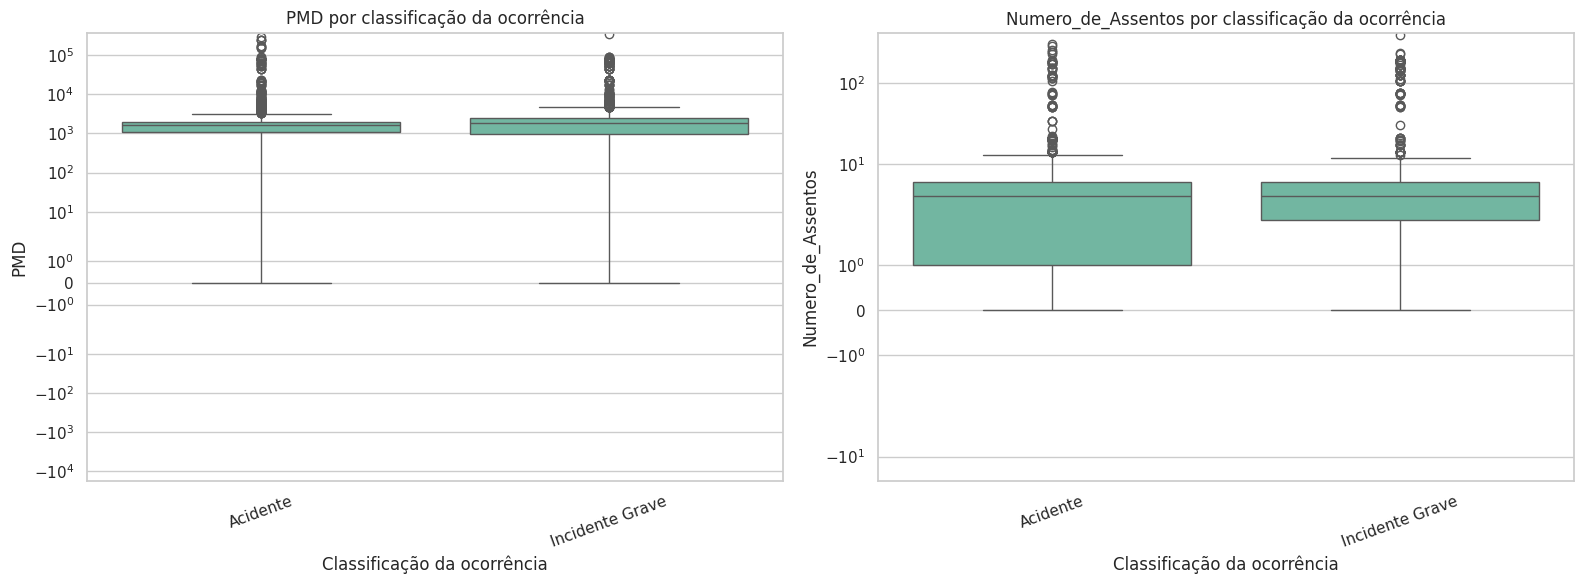

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
order = df[TARGET].value_counts().index

for ax, col in zip(axes, NUMERIC_FEATURES):
    sns.boxplot(data=df, x=TARGET, y=col, order=order, ax=ax)
    ax.set_yscale("symlog")
    ax.set_title(f"{col} por classificação da ocorrência")
    ax.set_xlabel("Classificação da ocorrência")
    ax.set_ylabel(col)
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


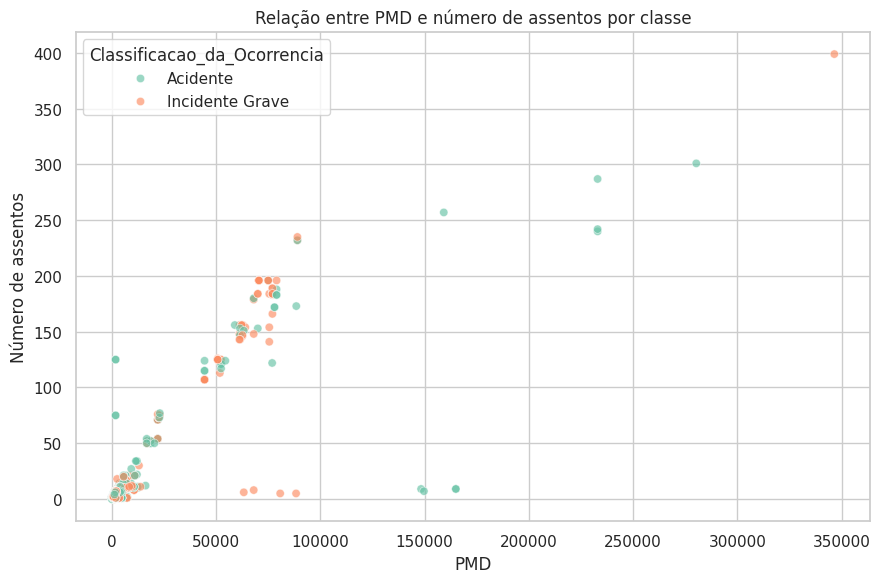

In [89]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x="PMD",
    y="Numero_de_Assentos",
    hue=TARGET,
    alpha=0.65,
)
plt.title("Relação entre PMD e número de assentos por classe")
plt.xlabel("PMD")
plt.ylabel("Número de assentos")
plt.tight_layout()
plt.show()


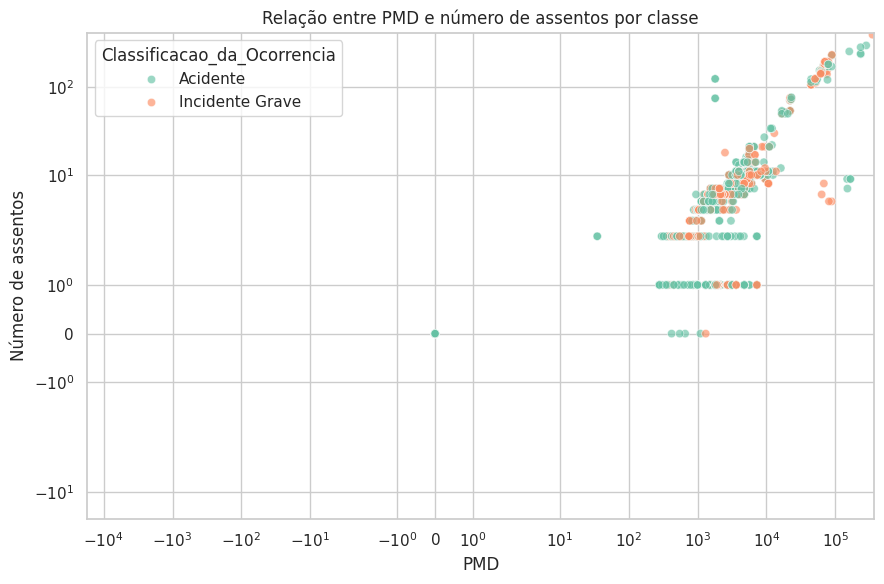

In [90]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x="PMD",
    y="Numero_de_Assentos",
    hue=TARGET,
    alpha=0.65,
)
plt.xscale("symlog")
plt.yscale("symlog")
plt.title("Relação entre PMD e número de assentos por classe")
plt.xlabel("PMD")
plt.ylabel("Número de assentos")
plt.tight_layout()
plt.show()

**Leitura inicial**

As classes aparecem misturadas nas distribuições de porte da aeronave, então `PMD` e `Numero_de_Assentos` provavelmente não serão suficientes sozinhas para separar o alvo. Ainda assim, os outliers e a concentração de aeronaves pequenas indicam que essas variáveis podem contribuir quando combinadas com fase da operação, operação e região.


## 6. Matriz de correlação


In [91]:
corr = df.corr(numeric_only=True)
corr

,Numero_da_Ocorrencia,PMD,Numero_de_Assentos
Numero_da_Ocorrencia,1.000000,-0.023493,-0.031842
PMD,-0.023493,1.000000,0.855599
Numero_de_Assentos,-0.031842,0.855599,1.000000


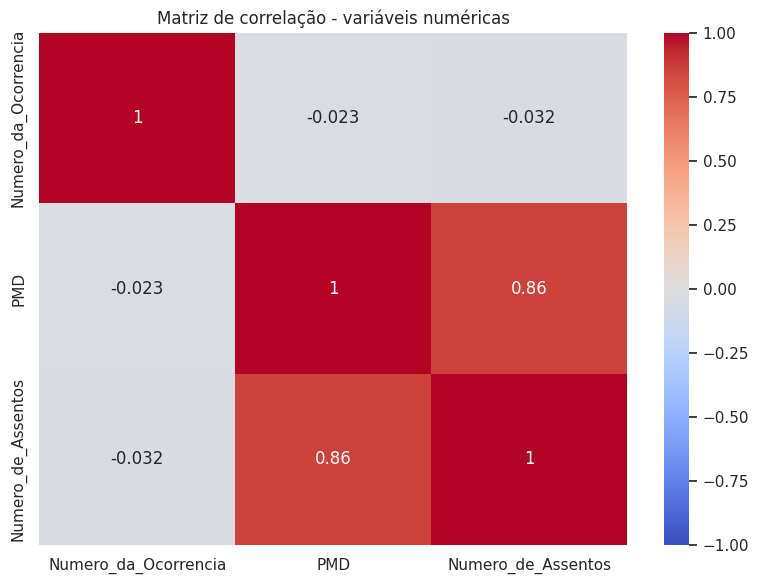

In [92]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Matriz de correlação - variáveis numéricas")
plt.tight_layout()
plt.show()

In [93]:
high_corr = []
for i, col_a in enumerate(corr.columns):
    for col_b in corr.columns[i + 1:]:
        r = corr.loc[col_a, col_b]
        if pd.notna(r) and abs(r) >= 0.7:
            high_corr.append({"feature_1": col_a, "feature_2": col_b, "correlacao": round(r, 3)})

pd.DataFrame(high_corr)


,feature_1,feature_2,correlacao
0,PMD,Numero_de_Assentos,0.856


**Diagnóstico**

`PMD` e `Numero_de_Assentos` apresentam correlação forte positiva, acima de 0,7. Isso indica multicolinearidade: aeronaves com maior peso máximo de decolagem tendem a ter mais assentos. Em modelos lineares, vale testar remoção de uma delas, regularização ou transformação; em modelos de árvore, a multicolinearidade tende a ser menos problemática, mas ainda pode afetar interpretação de importância.


## 7. Identificação de problemas


In [94]:
missing_summary = df.isnull().sum().sort_values(ascending=False)
missing_summary[missing_summary > 0]

Tipo_de_Aerodromo        3449
ICAO                     3334
Aerodromo_de_Destino     2138
Aerodromo_de_Origem      2117
Latitude                 1490
Longitude                1490
Hora_da_Ocorrencia       1433
Municipio                1394
Fase_da_Operacao         1300
Regiao                    670
Tipo_de_Ocorrencia        642
Descricao_do_Tipo         642
Nome_do_Fabricante        291
Historico                 265
CLS                       175
Modelo                    163
Tipo_ICAO                 158
Numero_de_Assentos        149
PMD                       145
Operacao                   94
Operador                   76
Operador_Padronizado       76
Categoria_da_Aeronave       9
Matricula                   4
UF                          3
Numero_da_Ficha             2
dtype: int64

In [95]:
df.duplicated().sum()

np.int64(10)

In [96]:
def iqr_outlier_summary(dataframe, columns):
    rows = []
    for col in columns:
        q1 = dataframe[col].quantile(0.25)
        q3 = dataframe[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        outliers = dataframe[(dataframe[col] < lower) | (dataframe[col] > upper)]
        rows.append({
            "feature": col,
            "q1": q1,
            "q3": q3,
            "iqr": iqr,
            "limite_inferior": lower,
            "limite_superior": upper,
            "qtd_outliers": len(outliers),
            "pct_outliers": round(len(outliers) / len(dataframe) * 100, 2),
        })
    return pd.DataFrame(rows)

iqr_outlier_summary(df, NUMERIC_FEATURES)


,feature,q1,q3,iqr,limite_inferior,limite_superior,qtd_outliers,pct_outliers
0,PMD,1043.0,2155.0,1112.0,-625.0,3823.0,492,9.80
1,Numero_de_Assentos,2.0,6.0,4.0,-4.0,12.0,204,4.06


In [97]:
data_ocorrencia = pd.to_datetime(df["Data_da_Ocorrencia"], errors="coerce")
latitude_num = pd.to_numeric(df["Latitude"].astype(str).str.replace(",", ".", regex=False), errors="coerce")
longitude_num = pd.to_numeric(df["Longitude"].astype(str).str.replace(",", ".", regex=False), errors="coerce")

quality_checks = pd.Series({
    "datas_invalidas": data_ocorrencia.isna().sum(),
    "datas_no_futuro": (data_ocorrencia > pd.Timestamp.today().normalize()).sum(),
    "PMD_menor_ou_igual_zero": (df["PMD"] <= 0).sum(),
    "Numero_de_Assentos_menor_ou_igual_zero": (df["Numero_de_Assentos"] <= 0).sum(),
    "latitude_malformada": latitude_num.isna().sum() - df["Latitude"].isna().sum(),
    "longitude_malformada": longitude_num.isna().sum() - df["Longitude"].isna().sum(),
    "latitude_fora_do_intervalo": ((latitude_num < -90) | (latitude_num > 90)).sum(),
    "longitude_fora_do_intervalo": ((longitude_num < -180) | (longitude_num > 180)).sum(),
    "matricula_mascarada_com_asteriscos": df["Matricula"].astype(str).str.fullmatch(r"\*+").sum(),
})
quality_checks


datas_invalidas                            0
datas_no_futuro                            0
PMD_menor_ou_igual_zero                   22
Numero_de_Assentos_menor_ou_igual_zero    27
latitude_malformada                        0
longitude_malformada                       0
latitude_fora_do_intervalo                 6
longitude_fora_do_intervalo                1
matricula_mascarada_com_asteriscos        14
dtype: int64

**Problemas identificados**

- Há valores ausentes em várias colunas, com maior impacto em campos como aeródromo, localização, horário, município e fase da operação.
- Existem linhas duplicadas completas, que devem ser removidas para evitar repetição artificial de amostras.
- `PMD` e `Numero_de_Assentos` possuem outliers pelo critério IQR, coerentes com aeronaves de portes muito diferentes.
- Existem valores impossíveis ou não úteis para modelagem direta em `PMD <= 0` e `Numero_de_Assentos <= 0`.
- `Latitude` e `Longitude` estão em formato textual com vírgula decimal; alguns registros ficam fora do intervalo geográfico válido.
- Matrículas mascaradas com asteriscos indicam strings sem valor informativo real.


## 8. Decisões de limpeza


In [98]:
cleaning_decisions = pd.DataFrame([
    {
        "problema": "Colunas de danos e lesões",
        "decisao": "Remover",
        "justificativa": "São informações conhecidas após a ocorrência e causam vazamento de dados.",
    },
    {
        "problema": "Datas como object",
        "decisao": "Converter para datetime e derivar ano/mes se houver uso temporal",
        "justificativa": "Permite validação, ordenação e criação de features temporais consistentes.",
    },
    {
        "problema": "Latitude/Longitude como texto e com vírgula decimal",
        "decisao": "Converter para float; marcar inválidos como ausentes",
        "justificativa": "O formato atual impede análise numérica/geográfica e há registros fora do intervalo válido.",
    },
    {
        "problema": "Valores ausentes em categóricas selecionadas",
        "decisao": "Imputar categoria 'Desconhecido' e criar flag quando fizer sentido",
        "justificativa": "Ausência pode carregar informação operacional e evita perda excessiva de linhas.",
    },
    {
        "problema": "Valores ausentes em PMD e Numero_de_Assentos",
        "decisao": "Imputar mediana por grupo, como Modelo ou Tipo_ICAO; usar mediana global como fallback",
        "justificativa": "Preserva registros e respeita diferenças esperadas entre tipos de aeronave.",
    },
    {
        "problema": "PMD <= 0 ou Numero_de_Assentos <= 0",
        "decisao": "Tratar como ausente antes da imputação",
        "justificativa": "Peso e assentos iguais ou menores que zero são incompatíveis com o domínio.",
    },
    {
        "problema": "Outliers em PMD e Numero_de_Assentos",
        "decisao": "Manter, aplicar log1p e avaliar modelos robustos",
        "justificativa": "Outliers representam aeronaves grandes reais; removê-los pode eliminar casos relevantes.",
    },
    {
        "problema": "Alta cardinalidade em Matricula, Operador_Padronizado, Municipio e Modelo",
        "decisao": "Evitar one-hot direto; agrupar raras ou usar encoding regularizado se forem usadas",
        "justificativa": "Reduz risco de overfitting e explosão dimensional.",
    },
    {
        "problema": "Duplicatas completas",
        "decisao": "Remover antes do treino",
        "justificativa": "Evita que registros repetidos distorçam treino, validação e métricas.",
    },
])
cleaning_decisions


,problema,decisao,justificativa
0,Colunas de danos e lesões,Remover,São informações conhecidas após a ocorrência e...
1,Datas como object,Converter para datetime e derivar ano/mes se h...,"Permite validação, ordenação e criação de feat..."
2,Latitude/Longitude como texto e com vírgula de...,Converter para float; marcar inválidos como au...,O formato atual impede análise numérica/geográ...
3,Valores ausentes em categóricas selecionadas,Imputar categoria 'Desconhecido' e criar flag ...,Ausência pode carregar informação operacional ...
4,Valores ausentes em PMD e Numero_de_Assentos,"Imputar mediana por grupo, como Modelo ou Tipo...",Preserva registros e respeita diferenças esper...
5,PMD <= 0 ou Numero_de_Assentos <= 0,Tratar como ausente antes da imputação,Peso e assentos iguais ou menores que zero são...
6,Outliers em PMD e Numero_de_Assentos,"Manter, aplicar log1p e avaliar modelos robustos",Outliers representam aeronaves grandes reais; ...
7,"Alta cardinalidade em Matricula, Operador_Padr...",Evitar one-hot direto; agrupar raras ou usar e...,Reduz risco de overfitting e explosão dimensio...
8,Duplicatas completas,Remover antes do treino,Evita que registros repetidos distorçam treino...


## 9. Insights da EDA para modelagem

1. A variável-alvo é desbalanceada: `Acidente` é majoritária e `Incidente Grave` é minoritária. A modelagem deve usar validação estratificada e métricas como `f1_macro`, não apenas acurácia.
2. `PMD` e `Numero_de_Assentos` têm cauda longa e outliers relevantes. A transformação `log1p` deve ser testada, principalmente em modelos lineares ou baseados em distância.
3. `PMD` e `Numero_de_Assentos` são fortemente correlacionadas, indicando multicolinearidade. Para modelos lineares, convém testar regularização ou remoção de uma delas.
4. Variáveis como `Matricula`, `Operador_Padronizado`, `Municipio` e `Modelo` têm alta cardinalidade e muitas categorias raras. Elas não devem receber one-hot encoding direto sem agrupamento ou estratégia de encoding.
5. Há problemas de qualidade nos dados, especialmente ausências, duplicatas, coordenadas textuais e valores impossíveis em features numéricas. O pipeline de limpeza deve tratar esses pontos antes da separação treino/teste para evitar inconsistências.
